## Modelo con la categoria de Laptops y sus caracteristicas - CatBoost

In [1]:
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [2]:
ev3 = pd.read_csv('../../Datasets/evaluacion3.csv')
ev3.head(1)

,category,market_tier,condition,is_premium_brand,tech_generation,ram_gb,storage_gb,size_value,performance_value,power_wattage,...,product_rating,is_best_seller,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,log_original_price,log_purchased_last_month,log_total_reviews
0,PC Components (Core),Mainstream,New,False,Current-Gen,NaN,2048.0,NaN,NaN,NaN,...,4.4,No Badge,Sponsored,1,0,0,0.0,5.484755,0.0,5.883322


In [3]:
# 1. Filtrar solo la categoría de laptops
# Nota: Asegúrate de que 'laptops' es el nombre exacto en tu columna 'category'
target_category = 'Laptops & Chromebooks' 

df_laptops = ev3[ev3['category'] == target_category].copy()

print(f"📦 Tamaño del dataset de Laptops: {len(df_laptops)} filas.")

# 2. Identificar columnas que NO son nulas para Laptops
# Vamos a quedarnos con columnas que tengan al menos un 30% de datos rellenos
threshold = 0.3
cols_to_keep = df_laptops.columns[df_laptops.isnull().mean() < (1 - threshold)].tolist()

# Nos aseguramos de mantener las importantes y el target
essential_cols = ['ram_gb', 'storage_gb', 'cpu_gpu_tier', 'log_original_price']
for c in essential_cols:
    if c not in cols_to_keep and c in df_laptops.columns:
        cols_to_keep.append(c)

df_laptops_final = df_laptops[cols_to_keep].copy()

print(f"✂️ Columnas mantenidas para el experto en Laptops: {len(cols_to_keep)}")
print(f"Variables técnicas incluidas: {[c for c in essential_cols if c in cols_to_keep]}")

📦 Tamaño del dataset de Laptops: 322 filas.
✂️ Columnas mantenidas para el experto en Laptops: 25
Variables técnicas incluidas: ['ram_gb', 'storage_gb', 'cpu_gpu_tier', 'log_original_price']


In [6]:
df_laptops_final.head(1)

,category,market_tier,condition,is_premium_brand,tech_generation,ram_gb,storage_gb,size_value,performance_value,resolution_standard,...,product_rating,is_best_seller,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,log_original_price,log_purchased_last_month,log_total_reviews
21,Laptops & Chromebooks,Premium,New,True,Current-Gen,16.0,256.0,13.6,12.0,2K/QHD (1440p),...,4.8,Best Seller,Organic,0,1,0,0.0,6.782135,9.21044,7.557473


In [5]:
df_laptops_final['cpu_gpu_tier'].value_counts()

cpu_gpu_tier
i7             20
Ryzen 5        18
i5             16
i3             12
Ryzen 7         9
               ..
N6000           1
Intel N6000     1
Dual-Core       1
M2              1
i3-1215U        1
Name: count, Length: 167, dtype: int64

In [7]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(df_laptops_final)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,category,334,0,object,1
1,market_tier,334,0,object,3
2,condition,334,0,object,2
3,is_premium_brand,334,0,object,2
4,tech_generation,334,0,object,3
5,ram_gb,319,15,float64,11
6,storage_gb,319,15,float64,25
7,size_value,322,12,float64,24
8,performance_value,154,180,float64,29
9,resolution_standard,270,64,object,5


In [20]:
# ==========================================
# 1. PREPARACIÓN DE DATOS (ESPECÍFICA LAPTOPS)
# ==========================================

# Definimos X e y
# Eliminamos el target y columnas que sepamos que sobran o son redundantes
X_lap = df_laptops_final.drop(columns=['log_original_price'])
y_lap = df_laptops_final['log_original_price']

# Detectar columnas categóricas automáticamente
cat_cols_lap = X_lap.select_dtypes(include=['object', 'category']).columns.tolist()

# IMPORTANTE: Rellenar nulos categóricos con "None" para CatBoost
# Con 334 filas, perder una sola fila por nulos es un lujo que no podemos darnos.
for col in cat_cols_lap:
    X_lap[col] = X_lap[col].astype(str).replace('nan', 'None')

# Obtener índices de las categóricas (CatBoost lo necesita así)
cat_indices_lap = [X_lap.columns.get_loc(c) for c in cat_cols_lap]

# Split 80/20 (Sin validación extra, usamos el Test para validar por ser pocos datos)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_lap, y_lap, test_size=0.20, random_state=42
)

print(f"Training con: {len(X_train_l)} laptops | Testeando con: {len(X_test_l)} laptops")

# ==========================================
# 2. ENTRENAMIENTO ROBUSTO (SIN OPTUNA)
# ==========================================

# Configuración conservadora para evitar overfitting en dataset pequeño
model_lap = CatBoostRegressor(
    iterations=2000,          # Suficientes iteraciones
    learning_rate=0.03,       # Lento para aprender bien
    depth=5,                  # Árboles poco profundos (clave para pocos datos)
    l2_leaf_reg=5,            # Regularización alta para evitar memorizar
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100,              # Imprimir cada 100 iters
    allow_writing_files=False
)

model_lap.fit(
    X_train_l, y_train_l,
    cat_features=cat_indices_lap,
    eval_set=(X_test_l, y_test_l), # Usamos Test como validación aquí por falta de datos
    early_stopping_rounds=100
)



Training con: 257 laptops | Testeando con: 65 laptops
0:	learn: 0.7500486	test: 0.7601092	best: 0.7601092 (0)	total: 65.2ms	remaining: 2m 10s
100:	learn: 0.3164122	test: 0.3480951	best: 0.3480951 (100)	total: 1.6s	remaining: 30.1s
200:	learn: 0.2475534	test: 0.3047975	best: 0.3047975 (200)	total: 3.07s	remaining: 27.5s
300:	learn: 0.2164196	test: 0.2905100	best: 0.2905060 (295)	total: 4.58s	remaining: 25.8s
400:	learn: 0.1976124	test: 0.2876316	best: 0.2874450 (384)	total: 6.15s	remaining: 24.5s
500:	learn: 0.1814176	test: 0.2851377	best: 0.2851377 (500)	total: 7.61s	remaining: 22.8s
600:	learn: 0.1682229	test: 0.2841922	best: 0.2840268 (591)	total: 9.11s	remaining: 21.2s
700:	learn: 0.1567834	test: 0.2817202	best: 0.2817194 (694)	total: 10.8s	remaining: 20s
800:	learn: 0.1473351	test: 0.2804721	best: 0.2800674 (753)	total: 12.4s	remaining: 18.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.2800674223
bestIteration = 753

Shrink model to first 754 iterations.



💻 RESULTADOS MODELO EXPERTO (LAPTOPS)
R²:       0.7208
MAE:      234.94 €
RMSE:     394.43 €
📊 Error Porcentual Medio (MAPE): 23.77%


C:\Users\diego\AppData\Local\Temp\ipykernel_9772\1079193884.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


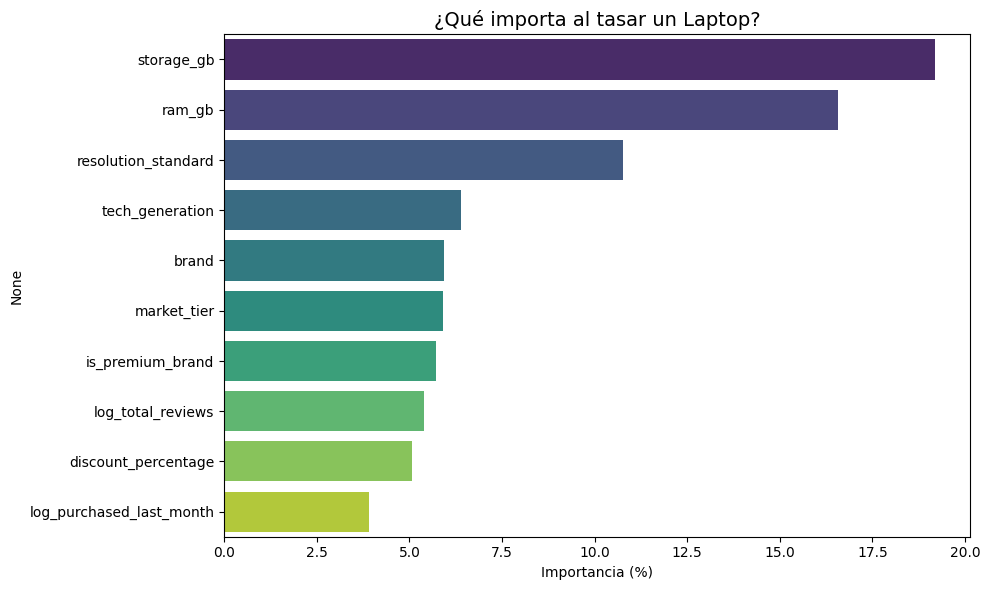

In [21]:


# ==========================================
# 3. EVALUACIÓN DE MÉTRICAS
# ==========================================

# Predicciones
p_lap_log = model_lap.predict(X_test_l)

# Inversión a Euros
p_lap_eur = np.expm1(p_lap_log)
y_lap_eur = np.expm1(y_test_l)

# Cálculo
mse_l = mean_squared_error(y_lap_eur, p_lap_eur)
mae_l = mean_absolute_error(y_lap_eur, p_lap_eur)
mape_lap = np.mean(np.abs((y_lap_eur - p_lap_eur) / y_lap_eur)) * 100
r2_l = r2_score(y_lap_eur, p_lap_eur)

print("\n" + "="*50)
print("💻 RESULTADOS MODELO EXPERTO (LAPTOPS)")
print("="*50)
print(f"R²:       {r2_l:.4f}")
print(f"MAE:      {mae_l:.2f} €")
print(f"RMSE:     {np.sqrt(mse_l):.2f} €")
print(f"📊 Error Porcentual Medio (MAPE): {mape_lap:.2f}%")
print("="*50)

# ==========================================
# 4. IMPORTANCIA DE VARIABLES (LA PRUEBA DE FUEGO)
# ==========================================

feature_importance = model_lap.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 6))
plt.title("¿Qué importa al tasar un Laptop?", fontsize=14)
sns.barplot(
    x=feature_importance[sorted_idx][:10], 
    y=X_lap.columns[sorted_idx][:10], 
    palette="viridis"
)
plt.xlabel("Importancia (%)")
plt.tight_layout()
plt.show()# Cálculo del error porcentual (MAPE)


In [ ]:
# --- CONFIGURACIÓN DE GUARDADO ---
base_folder = 'modelos/laptops'
model_filename = 'catboost_laptops_expert.cbm'
metadata_filename = 'catboost_laptops_metadata.json'

# Crear carpeta si no existe
os.makedirs(base_folder, exist_ok=True)

# Rutas completas
model_path = os.path.join(base_folder, model_filename)
metadata_path = os.path.join(base_folder, metadata_filename)

# 1. GUARDAR EL MODELO (Formato nativo CatBoost)
model_lap.save_model(model_path)

# 2. GUARDAR METADATA (Columnas y Orden)
# Esto es CRUCIAL: Guardamos qué columnas usa y el orden exacto
metadata = {
    'features': X_train_l.columns.tolist(),
    'cat_features_indices': cat_indices_lap,
    'target_category': 'Laptops & Chromebooks',
    'metrics_test': {
        'R2': 0.7208,
        'MAPE': 23.77,
        'RMSE': 394.43
    }
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"✅ MODELO GUARDADO EXITOSAMENTE")
print(f"📍 Ubicación: {os.path.abspath(base_folder)}")
print(f"📊 R² Final: 0.7208")

✅ MODELO GUARDADO EXITOSAMENTE
📍 Ubicación: d:\Documentos\diego\Master\Amazon-Smart-Pricing\Evaluaciones\Evaluacion_3\modelos\da
📊 R² Final: 0.7208
